# Using EarthSciLab for calculations with the InMAP Source Receptor Matrix (ISRM)

Author: Chris Tessum (ctessum@illinois.edu)

## Introduction

In the past, there have been three ways to interact with ISRM: 1) downloading the ISRM file and working with it locally; 2) using the service hosted at inmap.run, and 3) using the [Zarr](https://zarr.dev/) version of ISRM hosted online.

You will always be able to use ISRM on your own computer, but we will be removing (free) access to the two online options in favor of a new service which we will describe in this post. There are two reasons for this: 1) as usage has increased, making the online services available for free has become a financial burden; and 2) the new service offers capabilities that the two old options do not.

### earthscilab.com

[EarthSciLab](https://earthscilab.com) is an online service that allows users to specify a model as a system of equations, and then run the model either in their browser or using cloud computing resources. It is built on top of [EarthSciAST](https://github.com/EarthSciML/EarthSciAST), an open-source system for compiling equations into runnable model simulations.

Simulations that are run in EarthSciLab using your browser are free, but the service charges for simulations run using cloud computing resources, so that it is able to recoup the cost of those resources. Because the ISRM is a large file stored in the cloud, doing the calculations in this notebook using EarthSciLab may cost you a little bit. However, for calculations of the scale included in this notebook, the cost to you is minimal and may be zero.

### Bugs fixed compared to previous versions

While creating this tutorial, I found a couple of bugs in previous versions of ISRM and the code that interacted with it. Both of them have been fixed in this version, but have not yet been fixed in the older versions.

1. In the Go code for the `inmap srpredict` command that performed analyses using the ISRM, interpolations for plume rises that fell between available layers are performed backwards, so a plume that should have been near the bottom of a gap between layers was placed near the top, and vice versa. For more details and an analysis of the impacts, refer [here](https://github.com/spatialmodel/inmap/issues/121).

2. In the Zarr version of ISRM (at s3://inmap-model/isrm_v1.2.1.zarr), the `layers` variable which specified which vertical layers SR matrices had been calculated for read [0, 1, 2], when it should have said [0, 3, 6]. This has been fixed in a new version of the file at s3://inmap-model/isrm_v1.2.2.zarr, which has also be re-compressed to take up less space.

---
## Setup

Below is a bunch of code related to logging into the EarthSciLab service, setting up our ISRM calculation in the format required for EarthSciLab (which is a general service for evaluating geoscience equations and doesn't include any InMAP- or ISRM-related functionality itself), and actually running the simulation. You don't need to understand the code in the next cell in order to run your own analyses using ISRM.

In [ ]:
import base64
import copy
import io
import json
import pathlib
import ssl
import tempfile
import time
import urllib.error
import urllib.parse
import urllib.request
import webbrowser
import zipfile

import earthsci_ast
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import LineString, Polygon, box

API = "https://api.earthscilab.com"
WORKOS = "https://api.workos.com"
REPO_RAW = "https://raw.githubusercontent.com/EarthSciML/isrm.esm/main/"

_downloads = {}


def download(url):
    """`url`'s bytes, fetched once per kernel and kept in memory."""
    if url not in _downloads:
        with urllib.request.urlopen(url, timeout=900) as resp:
            _downloads[url] = resp.read()
        print(f"fetched {url.rsplit('/', 1)[-1]} ({len(_downloads[url]):,} bytes)")
    return _downloads[url]


class HttpError(Exception):
    def __init__(self, status, body, url):
        super().__init__(f"HTTP {status} from {url}: {body[:600]}")
        self.status, self.body = status, body


class OAuthError(Exception):
    """A 400 from WorkOS carrying an OAuth 2.0 `error` code."""
    def __init__(self, error, description):
        super().__init__(f"{error}: {description}")
        self.error = error


def _open(req, timeout):
    try:
        return urllib.request.urlopen(req, timeout=timeout, context=ssl.create_default_context())
    except urllib.error.HTTPError as e:
        body = e.read().decode("utf-8", "replace")
        try:
            payload = json.loads(body)
        except ValueError:
            payload = {}
        if e.code == 400 and "error" in payload:
            raise OAuthError(payload["error"], payload.get("error_description", "")) from None
        raise HttpError(e.code, body, req.full_url) from None


def http_json(method, url, *, json_body=None, form=None, raw=None, headers=None, timeout=120.0):
    """One request, JSON in and JSON out (or `None` for an empty 204 body)."""
    data, hdrs = None, dict(headers or {})
    if json_body is not None:
        data = json.dumps(json_body).encode()
        hdrs["Content-Type"] = "application/json"
    elif form is not None:
        data = urllib.parse.urlencode(form).encode()
        hdrs["Content-Type"] = "application/x-www-form-urlencoded"
    elif raw is not None:
        data = raw
        hdrs["Content-Type"] = "application/octet-stream"
    req = urllib.request.Request(url, data=data, headers=hdrs, method=method)
    with _open(req, timeout) as resp:
        body = resp.read()
    return json.loads(body) if body else None

class Session:
    """A signed-in EarthSciLab caller, refreshed on demand."""

    DEVICE_GRANT = "urn:ietf:params:oauth:grant-type:device_code"

    def __init__(self):
        self.client_id = http_json("GET", f"{API}/auth/config")["client_id"]
        self._access = None
        self._refresh_token = None

    @staticmethod
    def _expiry(token):
        if not token:
            return 0.0
        try:
            payload = token.split(".")[1]
            payload += "=" * (-len(payload) % 4)
            return float(json.loads(base64.urlsafe_b64decode(payload)).get("exp", 0))
        except Exception:
            return 0.0

    def _adopt(self, response):
        self._access = response["access_token"]
        # Refresh tokens ROTATE. Keeping the new one is not housekeeping — hold on
        # to the old one and the next refresh fails.
        if response.get("refresh_token"):
            self._refresh_token = response["refresh_token"]

    def _refresh(self):
        if not self._refresh_token:
            return False
        try:
            self._adopt(http_json("POST", f"{WORKOS}/user_management/authenticate", form={
                "grant_type": "refresh_token", "refresh_token": self._refresh_token,
                "client_id": self.client_id}))
            return True
        except OAuthError:
            self._refresh_token = None
            return False

    def login(self):
        start = http_json("POST", f"{WORKOS}/user_management/authorize/device",
                          form={"client_id": self.client_id})
        print(f"\n  Your code is:  {start['user_code']}")
        print(f"  Open: {start['verification_uri_complete']}\n")
        try:
            webbrowser.open(start["verification_uri_complete"])
        except Exception:
            pass
        interval = float(start.get("interval", 5))
        deadline = time.time() + float(start.get("expires_in", 300))
        while time.time() < deadline:
            time.sleep(interval)
            try:
                self._adopt(http_json("POST", f"{WORKOS}/user_management/authenticate", form={
                    "grant_type": self.DEVICE_GRANT, "device_code": start["device_code"],
                    "client_id": self.client_id}))
                return
            except OAuthError as e:
                if e.error == "authorization_pending":
                    continue
                if e.error == "slow_down":
                    interval += 1
                    continue
                raise RuntimeError(f"sign-in refused: {e}") from None
        raise RuntimeError("sign-in timed out; run this cell again")

    def headers(self):
        if time.time() > self._expiry(self._access) - 60:
            if not self._refresh():
                self.login()
        return {"Authorization": f"Bearer {self._access}"}

    def get(self, path, timeout=120.0):
        return http_json("GET", f"{API}{path}", headers=self.headers(), timeout=timeout)

    def post(self, path, body=None, timeout=300.0):
        return http_json("POST", f"{API}{path}", json_body=body,
                         headers=self.headers(), timeout=timeout)

    def put_bytes(self, path, payload, timeout=600.0):
        return http_json("PUT", f"{API}{path}", raw=payload,
                         headers=self.headers(), timeout=timeout)

    def stream(self, path, timeout):
        headers = dict(self.headers(), Accept="text/event-stream")
        req = urllib.request.Request(f"{API}{path}", headers=headers, method="GET")
        return _open(req, timeout)


# Each emission column, and the SR pathway it feeds.
PATHWAYS = {"PM25": "PrimaryPM25", "VOC": "SOA", "NOx": "pNO3",
            "NH3": "pNH4", "SOx": "pSO4"}
STACK = ["STKHGT", "STKDIAM", "STKTEMP", "STKVEL"]

TOTALS = ["TotalPM25", "deathsK", "deathsL"]
CELL = ["rcv_W", "rcv_S", "rcv_E", "rcv_N"]      # each receptor's own rectangle
OBSERVEDS = TOTALS + CELL

# The InMAP grid's own projection, and a SPHERE rather than an ellipsoid. The
# documents project lon/lat with these same parameters, so a length or an area
# measured here is the one the document measures.
LCC = ("+proj=lcc +lat_1=33 +lat_2=45 +lat_0=40 +lon_0=-97 "
       "+a=6370997 +b=6370997 +units=m +no_defs")

# The readers declare a file's CRS and reproject nothing, and the documents do
# the projection themselves, so the file goes out geographic.
FILE_CRS = "EPSG:4269"

FAMILIES = {"Point": "point", "MultiPoint": "point",
            "Polygon": "polygon", "MultiPolygon": "polygon",
            "LineString": "line", "MultiLineString": "line"}

TEMPLATES = {("point", True): "isrm_gdf_point.esm",
             ("point", False): "isrm_gdf_point_flat.esm",
             ("polygon", False): "isrm_gdf_polygon.esm",
             ("line", False): "isrm_gdf_line.esm"}

# `GET /datasets/{id}/field` clamps to this and a query cannot raise it. The
# receptor axis is 52,411, so a whole field fits and comes back at stride 1.
MAX_VALUES = 262_144


def _explode(gdf, columns):
    """One row per part, with every emission column split among the parts."""
    multi = int(gdf.geom_type.str.startswith("Multi").sum())
    gdf = gdf.reset_index(drop=True)          # so the parent index is unique
    parts = gdf.explode(index_parts=False)    # ... and repeated once per part
    if len(parts) == len(gdf):
        return parts.reset_index(drop=True)

    measure = parts.geometry.area
    if not (measure > 0).any():
        measure = parts.geometry.length
    if not (measure > 0).any():               # points: all a point has is its count
        measure = pd.Series(1.0, index=parts.index)
    share = measure / measure.groupby(level=0).transform("sum")

    parts = parts.copy()
    for column in columns:
        parts[column] = parts[column].astype(float) * share
    print(f"  split {multi} multi-part record(s) into {len(parts) - len(gdf)} extra "
          f"part(s), emissions shared by area/length")
    return parts.reset_index(drop=True)


def _drop_holes(gdf):
    """Replace each polygon by its exterior ring."""
    holes = int(sum(len(g.interiors) for g in gdf.geometry))
    if not holes:
        return gdf
    gdf = gdf.copy()
    gdf["geometry"] = [Polygon(g.exterior) for g in gdf.geometry]
    print(f"  dropped {holes} interior ring(s); mass unchanged, footprint now "
          f"includes the holes")
    return gdf


def _segmentize(gdf, columns):
    """Cut every polyline into two-vertex segments, emission split by length."""
    rows = []
    for _, record in gdf.iterrows():
        coords = list(record.geometry.coords)
        segments = [LineString([a, b]) for a, b in zip(coords, coords[1:])]
        lengths = np.array([s.length for s in segments], dtype=float)
        share = (lengths / lengths.sum() if lengths.sum() > 0
                 else np.full(len(segments), 1.0 / len(segments)))
        for segment, fraction in zip(segments, share):
            rows.append({**{c: float(record[c]) * fraction for c in columns},
                         "geometry": segment})
    print(f"  cut {len(gdf)} polyline(s) into {len(rows)} two-vertex segment(s)")
    return gpd.GeoDataFrame(rows, geometry="geometry", crs=gdf.crs)


def normalize(gdf):
    """A frame the reader can be handed, and what the document needs to know."""
    if gdf.crs is None:
        raise ValueError("the frame has no CRS; set one so it can be reprojected to "
                         "the geographic CRS the documents project from")

    columns = [c for c in PATHWAYS if c in gdf.columns]
    if not columns:
        raise ValueError(f"no emission column: expected one or more of "
                         f"{list(PATHWAYS)} in kg/yr, got {list(gdf.columns)}")

    families = {FAMILIES.get(t) for t in gdf.geom_type.unique()}
    if len(families) != 1 or None in families:
        raise ValueError(f"one geometry family per frame; got "
                         f"{sorted(gdf.geom_type.unique())}")
    family = families.pop()

    stack = [c for c in STACK if c in gdf.columns]
    plume = family == "point" and len(stack) == len(STACK)
    if family == "point" and stack and not plume:
        raise ValueError(f"plume rise needs all of {STACK}; the frame has {stack}")

    # Work in the grid's own metres: every share below is a ratio of areas or
    # lengths, and the document computes them in this same projection.
    frame = _explode(gdf.to_crs(LCC), columns)
    if family == "polygon":
        frame = _drop_holes(frame)
    if family == "line":
        frame = _segmentize(frame, columns)

    keep = columns + (STACK if plume else [])
    frame = frame[keep + ["geometry"]].copy()
    for column in keep:
        frame[column] = np.asarray(frame[column], dtype=float)

    # The vertex axis the reader pads to, and the document declares.
    nvert_max = (1 if family == "point" else
                 2 if family == "line" else
                 max(len(g.exterior.coords) for g in frame.geometry))

    frame = frame.to_crs(FILE_CRS)
    print(f"  {len(frame):,} records · {family} · nvert_max {nvert_max} · "
          f"{', '.join(keep)}" + (" · ASME plume rise" if plume else ""))
    return frame, family, columns, plume, nvert_max


def shapefile_zip(frame):
    """The frame as a zipped four-file shapefile set, in memory.

    GDAL writes a shapefile as several files with a shared stem, so this is the
    one step that needs a directory — a temporary one, gone on the way out.
    `emis.shp` is the member every generated document names.
    """
    with tempfile.TemporaryDirectory() as tmp:
        frame.to_file(pathlib.Path(tmp) / "emis.shp", driver="ESRI Shapefile",
                      engine="pyogrio")
        buffer = io.BytesIO()
        with zipfile.ZipFile(buffer, "w") as archive:
            for part in sorted(pathlib.Path(tmp).iterdir()):
                archive.writestr(part.name, part.read_bytes())
    return buffer.getvalue()


def equation_refs(doc):
    """`lhs` -> every variable its right-hand side needs."""
    loaded = earthsci_ast.load_document(copy.deepcopy(doc))
    model = loaded.models[next(iter(doc["models"]))]
    return {eq.lhs: earthsci_ast.free_variables(eq.rhs) for eq in model.equations}


def prune_pathways(doc, columns):
    """Keep only the pathways the frame has columns for."""
    model = doc["models"]["ISRM"]
    variables, equations = model["variables"], model["equations"]
    report = doc["metadata"]["x_esd"]["report"]

    keep = [PATHWAYS[c] for c in columns]
    report["pathways"] = [p for p in report["pathways"] if p["sr_array"] in keep]

    total = next(e for e in equations if e["lhs"] == "TotalPM25")
    terms = [{"op": "index", "args": [f"conc_{p}", "rcv"]} for p in keep]
    total["rhs"]["args"] = [f"conc_{p}" for p in keep]
    total["rhs"]["expr"]["args"][1] = ({"op": "+", "args": terms} if len(terms) > 1
                                       else terms[0])

    roots = [report["total_pm25"], *report["deaths"].values(), report["record_field"],
             *CELL, "rcv_cx", "rcv_cy"]
    for pathway in report["pathways"]:
        roots += [pathway["concentration"], *pathway["emissions"],
                  "pm_" + pathway["sr_array"]]

    refs = equation_refs(doc)
    needed, stack = set(), list(roots)
    while stack:
        name = stack.pop()
        if name in needed or name not in variables:
            continue
        needed.add(name)
        stack.extend(refs.get(name, set()) & set(variables))

    dropped = sorted(set(variables) - needed)
    model["variables"] = {n: v for n, v in variables.items() if n in needed}
    model["equations"] = [e for e in equations if e["lhs"] in needed]
    live = {(v.get("update") or {}).get("source") for v in model["variables"].values()}
    for source in [s for s in doc["data_sources"] if s not in live]:
        doc["data_sources"].pop(source)
        dropped.append(source)
    if dropped:
        print(f"  pruned {len(dropped)} variable(s)/source(s); {len(keep)} pathway(s) "
              f"kept: {', '.join(keep)}")
    return doc


def fold_in_template_library(doc):
    """Merge the imported `expression_templates` in, and drop the import key.

    Not using `earthsci_ast.emit_document` because it closes the metaparameters 
    into the index sets, turning `emis_records: {size: "N_REC"}` into `{size: 0}`.
    """
    for model in doc["models"].values():
        merged = {}
        for imported in model.pop("expression_template_imports", []) or []:
            library = json.loads(download(REPO_RAW + imported["ref"].rsplit("/", 1)[-1]))
            merged.update(library.get("expression_templates") or {})
        merged.update(model.get("expression_templates") or {})   # the document's own win
        model["expression_templates"] = merged
    return doc


def build_document(family, plume, columns, nvert_max, url, records=None):
    """The template, made into the document this particular frame needs."""
    name = TEMPLATES[(family, plume)]
    doc = fold_in_template_library(json.loads(download(REPO_RAW + name)))

    source = doc["data_sources"]["Emis"]
    source["source"]["url_template"] = url

    # `nvert_max` is TWO declarations that have to agree: what the reader pads the
    # vertex axis to, and how wide the document says that axis is. Setting only
    # the reader's half is not a validation error and not a wrong number — the
    # engine reads a [records, 5, 2] array into a [records, 56, 2] parameter and
    # the worker dies with no message at all. The axis is found through the
    # geometry variable rather than by name, because each family calls it
    # something different (N_EVERT, N_PVERT, N_LVERT).
    source["reader_options"]["nvert_max"] = nvert_max
    model = doc["models"]["ISRM"]
    geometry = next(name for name, v in model["variables"].items()
                    if ((v.get("update") or {}).get("from") or {})
                    .get("file_variable") == "geometry")
    axis = model["variables"][geometry]["shape"][1]
    doc["metaparameters"][doc["index_sets"][axis]["size"]]["default"] = nvert_max

    if records:
        # Scale is a DOCUMENT edit, not a request parameter: a loader-level
        # `select` range on the source that discovers its own extent.
        source["select"] = {"axes": [{"range": {"start": 0, "stop": records}}]}

    prune_pathways(doc, columns)

    # Cheaper to hear it from the library than from the API, which rejects an
    # invalid document with a bare "not valid under any of the schemas listed in
    # the 'oneOf' keyword" and 60 KB of echoed model, naming nothing.
    result = earthsci_ast.validate(earthsci_ast.load_document(copy.deepcopy(doc)))
    problems = list(result.schema_errors) + list(result.structural_errors)
    if problems:
        raise RuntimeError("the document this frame produced is invalid:\n  "
                           + "\n  ".join(str(p) for p in problems[:6]))

    print(f"  {name} · {axis} width {nvert_max} · valid"
          + (f" · first {records:,} records" if records else ""))
    return doc

TERMINAL = {"succeeded", "failed", "cancelled", "capped"}


def money(dollars):
    return "—" if dollars is None else (
        f"${dollars:.4f}" if 0 < abs(dollars) < 0.01 else f"${dollars:.2f}")


def clock(seconds):
    seconds = int(seconds)
    if seconds >= 3600:
        return f"{seconds // 3600}h{seconds % 3600 // 60:02d}m"
    return f"{seconds // 60}m{seconds % 60:02d}s" if seconds >= 60 else f"{seconds}s"


def upload_dataset(session, payload, name, esio_format="shapefile"):
    """Put bytes in the dataset store under `name`; return the committed record."""
    created = session.post("/datasets", {"format": esio_format, "origin": "upload"})
    if created["upload"]["mode"] != "proxy":
        raise RuntimeError(f"this deployment wants a {created['upload']['mode']!r} "
                           "upload, not a proxied one")
    if len(payload) > created["max_object_bytes"]:
        raise RuntimeError(f"{name} is {len(payload):,} B, over the "
                           f"{created['max_object_bytes']:,} B per-object ceiling")
    session.put_bytes(f"{created['upload']['url']}?key={urllib.parse.quote(name)}",
                      payload)
    dataset = session.post(f"/datasets/{created['id']}/commit")
    print(f"  uploaded {name} ({len(payload):,} B) as dataset {dataset['id']}")
    return dataset


def dataset_url(dataset):
    """Where a document's `url_template` should point at this dataset."""
    base = dataset["store_url"].rstrip("/")
    return base if dataset.get("format") == "zarr" else f"{base}/{dataset['object_key']}"


def quote(doc, observeds):
    """Price the run. No auth — `POST /quote` has no database."""
    routing = http_json("POST", f"{API}/quote", timeout=300.0,
                        json_body={"esm": doc, "kind": "evaluate",
                                   "observeds": observeds})
    option = routing.get("dispatchable")
    if not option:
        raise RuntimeError(f"no dispatchable backend: {routing.get('reason')}")
    estimate, sizing = option["estimate"], routing.get("sizing") or {}
    print(f"  {option['backend']} · {sizing.get('vcpus')} vCPU / "
          f"{sizing.get('memory_mb')} MB · {clock(estimate['resource_seconds'])} "
          f"predicted (cap {clock(estimate['max_resource_seconds'])}) · "
          f"{money(estimate['price'])}")
    return estimate["price"]


def watch(session, run_id):
    """Follow a run to a terminal event, surviving a dropped connection.

    The stream replays everything already recorded before it streams, so a
    reconnect sees what it missed — including a terminal event that landed while
    we were disconnected.
    """
    started = time.time()
    while True:
        try:
            with session.stream(f"/runs/{run_id}/events", timeout=240.0) as resp:
                for line in resp:
                    line = line.decode("utf-8", "replace").strip()
                    if not line.startswith("data:"):
                        continue
                    event = json.loads(line[5:]).get("kind") or {}
                    kind = event.get("type")
                    if kind == "progress":
                        f = event.get("fraction", 0.0)
                        print(f"\r  [{'#' * int(f * 40):<40}] {f * 100:5.1f}%  "
                              f"elapsed {clock(time.time() - started)}", end="", flush=True)
                    elif kind in ("queued", "started"):
                        print(f"  {kind}", flush=True)
                    elif kind in TERMINAL:
                        print()
                        return event
        except (HttpError, OAuthError, urllib.error.URLError, OSError, ValueError) as e:
            print(f"\n  (stream dropped: {e}; the run is server-side and unaffected)")
        run = session.get(f"/runs/{run_id}")
        if run["status"] in TERMINAL:
            return {"type": run["status"]}
        time.sleep(5)


def read_fields(session, dataset_id, names):
    """One 1-D array per name."""
    dataset = session.get(f"/datasets/{dataset_id}")
    pins = ",".join(f"{d['name']}:0" for d in dataset.get("dims", []) if d["size"] == 1)
    series = {}
    for name in names:
        query = {"var": name, "max_values": MAX_VALUES}
        if pins:
            query["at"] = pins
        field = session.get(f"/datasets/{dataset_id}/field?{urllib.parse.urlencode(query)}")
        if len(field["axes"]) != 1 or field["axes"][0]["stride"] != 1:
            raise RuntimeError(f"{name}: expected one free axis read whole: "
                               f"{field['axes']}")
        series[name] = field["values"]
    return series


def receptor_frame(series):
    """The answer as a GeoDataFrame: one cell rectangle per receptor.

    Handed back in the InMAP/EPA Lambert conformal projection
    Call `.to_crs(...)` to switch to another CRS.
    """
    cells = [box(w, s, e, n) for w, s, e, n in
             zip(series["rcv_W"], series["rcv_S"], series["rcv_E"], series["rcv_N"])]
    return gpd.GeoDataFrame({name: series[name] for name in TOTALS},
                            geometry=cells, crs=LCC)

def run_isrm(gdf, records=None, max_price=None):
    """Run the InMAP ISRM over `gdf` on EarthSciLab, and bring the answer back.

    `gdf` carries one row per source, geometry in any CRS, and a column per
    pollutant in kg/yr (see 2.1). Returns a GeoDataFrame of the 52,411 receptor
    cells with TotalPM25 in µg/m³ and the two mortality estimates, and the run's
    id in `.attrs`.
    """
    print("layer")
    frame, family, columns, plume, nvert_max = normalize(gdf)

    print("upload")
    dataset = upload_dataset(session, shapefile_zip(frame), "emis.zip")

    print("document")
    doc = build_document(family, plume, columns, nvert_max,
                         dataset_url(dataset), records=records)

    print("quote")
    price = quote(doc, OBSERVEDS)

    print("run")
    run = session.post("/runs", {
        "esm": doc, "kind": "evaluate", "observeds": OBSERVEDS,
        "max_price": price if max_price is None else max_price})
    print(f"  run {run['id']} — {run['status']} on {run['backend']}, "
          f"{money(run['price'])}")
    outcome = watch(session, run["id"])
    if outcome["type"] != "succeeded":
        raise RuntimeError(f"run {run['id']} {outcome['type']}: "
                           f"{outcome.get('message', '')}")
    print(f"  succeeded in {clock(outcome.get('resource_seconds', 0))} of resource time")

    receptors = receptor_frame(read_fields(session, outcome["dataset_id"], OBSERVEDS))
    receptors.attrs.update(run_id=run["id"], dataset_id=dataset["id"],
                           records=len(frame), pathways=columns)
    for name in TOTALS:
        print(f"  sum({name})".ljust(22) + repr(float(receptors[name].sum())))
    return receptors

### Sign in

Before you can run an analysis or simulation, you will need an EarthSciLab account. Go to https://earthscilab.com/ and click "Sign in" in the upper right corner of the page, then click "Sign up" and follow the instructions.

Once you have an account, run the code in the cell below and then follow the instructions to login to your account in this notebook.

In [2]:
session = Session()
print("signed in as", session.get("/me")["email"])
print("credit:", session.get("/credits"))

## Run an analysis

An order to calculate air quality impacts using ISRM in EarthSciLab, you will need a [GeoPandas](https://geopandas.org/en/stable/) GeoDataFrame including the geometry of each emissions record, plus the following information:

| column | units | meaning |
|---|---|---|
| `PM25` | kg/yr | emissions of primary PM2.5, resulting in `PrimaryPM25` concentrations |
| `NOx` | kg/yr | emissions of NOx, resulting in `pNO3` concentrations |
| `NH3` | kg/yr | emissions of NH3, resulting in  `pNH4` concentrations |
| `SOx` | kg/yr | emissions of SO2, resulting in `pSO4` concentrations |
| `VOC` | kg/yr | emissions of VOCs, resulting in `SOA` concentrations |
| `STKHGT` | m | stack height — POINT frames only |
| `STKDIAM` | m | stack exit diameter |
| `STKTEMP` | K | exit gas temperature |
| `STKVEL` | m/s | exit gas velocity |

Each record should either have information for all four stack parameter columns or for none. 
If the stack parameters are specified, a point source's mass is allocated to a vertical emission height using a plume rise algorithm; 
otherwise emissions are assumed to occur at ground level.

Below, we will demonstrate a couple of analyses to get you started:


### Example point source analysis

The cell below creates a function that download's a US EPA emissions inventory for electricity generating units (EGUs)
and processes it into the required geodataframe format described above:

In [4]:
FF10_URL = ("https://gaftp.epa.gov/air/emismod/2016/alpha/2016fd/emissions/"
            "2016fd_inputs_point.zip")

# FF10 point columns are positional (0-based), as EarthSciIO's own reader has
# them; isrm_point.esm's metadata.x_esd.columns names the same indices.
FF10 = {12: "POLID", 13: "ANN_VALUE", 17: "STKHGT", 18: "STKDIAM",
        19: "STKTEMP", 21: "STKVEL", 23: "LONGITUDE", 24: "LATITUDE"}

SHORT_TON_KG = 907.18474


def _compared_codes(node, found=None):
    """Every integer an `==` in this expression compares against.

    Collected by walking rather than by indexing, because the shape of a mask
    depends on how many codes it covers: `is_VOC` is an `or` of 35 `==` nodes
    and `is_NH3` is a single bare `==`.
    """
    found = set() if found is None else found
    if isinstance(node, dict):
        if node.get("op") == "==":
            args = node.get("args") or []
            if len(args) == 2 and isinstance(args[1], (int, float)):
                found.add(int(args[1]))
        for value in node.values():
            _compared_codes(value, found)
    elif isinstance(node, list):
        for item in node:
            _compared_codes(item, found)
    return found


def pollutant_classes():
    """`POLID` -> emission column, read out of isrm_point.esm itself."""
    model = json.loads(download(REPO_RAW + "isrm_point.esm"))["models"]["ISRM"]
    codes = model["variables"]["pollutant"]["update"]["from"]["codes"]["map"]
    classes = {}
    for column in PATHWAYS:
        mask = next(e for e in model["equations"] if e["lhs"] == f"is_{column}")
        wanted = _compared_codes(mask["rhs"])
        for polid, code in codes.items():
            if code in wanted:
                classes[polid.upper()] = column
    return classes


def egu_points(limit=None):
    """The EGU inventory as one row per stack, in SI units."""
    classes = pollutant_classes()
    with zipfile.ZipFile(io.BytesIO(download(FF10_URL))) as archive:
        member = next(n for n in archive.namelist()
                      if "egu" in n.lower() and not n.endswith("/"))
        raw = pd.read_csv(io.BytesIO(archive.read(member)), header=None, comment="#",
                          usecols=list(FF10), names=None, dtype=str,
                          engine="python", on_bad_lines="skip")
    raw = raw.rename(columns=FF10)
    # One asserted header line survives the '#' comments.
    if str(raw.iloc[0]["POLID"]).strip().lower() in ("polid", "poll"):
        raw = raw.iloc[1:]
    print(f"  {member}: {len(raw):,} FF10 rows")

    raw["column"] = raw["POLID"].str.strip().str.upper().map(classes)
    raw = raw.dropna(subset=["column"])
    numeric = ["ANN_VALUE", "STKHGT", "STKDIAM", "STKTEMP", "STKVEL",
               "LONGITUDE", "LATITUDE"]
    for name in numeric:
        raw[name] = pd.to_numeric(raw[name], errors="coerce")
    raw = raw.dropna(subset=numeric)
    print(f"  {len(raw):,} rows classified into {sorted(raw['column'].unique())}")

    # A stack IS its location plus its four parameters: rows that agree on all
    # six are the same physical stack, and summing them is exact for a linear
    # model. Pivoting on that key is what turns long into wide.
    key = ["LONGITUDE", "LATITUDE", "STKHGT", "STKDIAM", "STKTEMP", "STKVEL"]
    wide = (raw.pivot_table(index=key, columns="column", values="ANN_VALUE",
                            aggfunc="sum", fill_value=0.0)
               .reset_index())
    wide.columns.name = None
    print(f"  pivoted to {len(wide):,} stacks")
    if limit:
        wide = wide.head(limit)

    emissions = [c for c in PATHWAYS if c in wide.columns]
    for column in emissions:
        wide[column] = wide[column] * SHORT_TON_KG              # short ton/yr -> kg/yr
    wide["STKHGT"] = wide["STKHGT"] * 0.3048                    # ft -> m
    wide["STKDIAM"] = wide["STKDIAM"] * 0.3048
    wide["STKVEL"] = wide["STKVEL"] * 0.3048                    # ft/s -> m/s
    wide["STKTEMP"] = (wide["STKTEMP"] - 32.0) * 5.0 / 9.0 + 273.15   # degF -> K

    return gpd.GeoDataFrame(
        wide[emissions + STACK],
        geometry=gpd.points_from_xy(wide["LONGITUDE"], wide["LATITUDE"]),
        crs="EPSG:4269")

Now, we can run the function we created above to get the emissions geodataframe:

In [ ]:
points = egu_points(limit=100) # <- Change to limit=None to run the full inventory. The limit is just for a quick test.
print()
print(points[[c for c in PATHWAYS if c in points.columns]].sum().to_string())
points.head(3)

  2016fd_cb6_16j/inputs/ptegu/egucems_2016v2_POINT_20180327_HCLCLaug_12apr2018_v2.csv: 93,459 FF10 rows
  24,597 rows classified into ['NH3', 'NOx', 'PM25', 'SOx', 'VOC']
  pivoted to 2,159 stacks

PM25    1.336610e+06
VOC     5.199170e+05
NOx     4.129675e+06
NH3     9.602069e+05
SOx     3.480194e+06


,PM25,VOC,NOx,NH3,SOx,STKHGT,STKDIAM,STKTEMP,STKVEL,geometry
0,21772.433760,7348.196394,71331.936106,2068.381207,7457.058563,54.8640,4.2672,372.038889,0.272278,POINT (-122.6862 48.8287)
1,2449.398798,90.718474,8164.662660,3265.865064,544.310844,25.6032,3.3528,394.261111,21.153120,POINT (-122.487 48.7451)
2,1451.495584,90.718474,6350.293180,2177.243376,362.873896,25.6032,3.3528,394.261111,21.153120,POINT (-122.487 48.7454)


Now, we can run the `run_isrm` function we created at the top of the notebook to calculate the resulting PM2.5 concentrations. It can take a while, depending on how many emissions records you are processing. Also, there will be a progress bar but it may get stuck for a while at around 75%; this is normal.

In [23]:
point_receptors = run_isrm(points)

layer
  100 records · point · nvert_max 1 · PM25, VOC, NOx, NH3, SOx, STKHGT, STKDIAM, STKTEMP, STKVEL · ASME plume rise
upload
  uploaded emis.zip (26,476 B) as dataset 7e562bc1-6aea-4bdd-aab1-34b0c0b435b0
document
  isrm_gdf_point.esm · emis_vertex width 1 · valid
quote
  cloud_batch · 4.0 vCPU / 16384 MB · 10m00s predicted (cap 1h20m) · $0.04
run
  run 8a632caa-d3f0-41e5-babc-f53900505468 — running on cloud_batch, $0.04
  queued
  started
  [######################################  ]  96.3%  elapsed 2m32s
  succeeded in 2m11s of resource time
  sum(TotalPM25)      281.24156822422736
  sum(deathsK)        43.91889991152327
  sum(deathsL)        98.79455102893459


#### Plotting the result

The cell below creates a function to show our calculate concentrations or health impacts on a map:

In [24]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# `Blues` with its white end trimmed off: at pure white the lowest cells are
# invisible against the page.
SEQUENTIAL = ListedColormap(plt.get_cmap("Blues")(np.linspace(0.15, 1.0, 256)))

# State outlines, to give the concentration field somewhere to stand. 20m is the
# coarsest of the three cartographic generalisations the Census publishes — at
# the scale these maps are drawn at, the finer ones are only more vertices.
STATES_URL = ("https://www2.census.gov/geo/tiger/GENZ2020/shp/"
              "cb_2020_us_state_20m.zip")

_states = {}


def states():
    """State boundaries in the receptor grid's projection, read once."""
    if "gdf" not in _states:
        _states["gdf"] = gpd.read_file(io.BytesIO(download(STATES_URL))).to_crs(LCC)
    return _states["gdf"]


def show(receptors, title="", column="TotalPM25", units="µg/m³",
         clip_pct=99.0, share=1.0, height=6.4, boundaries=True):
    """The receptor grid as a choropleth."""
    v = receptors[column].to_numpy()
    vmax = np.percentile(v, clip_pct) or v.max() or 1.0

    bounds = receptors.total_bounds
    if share:
        order = np.argsort(v)[::-1]
        keep = order[:np.searchsorted(np.cumsum(v[order]), v.sum() * share) + 1]
        bounds = receptors.iloc[keep].total_bounds
    x0, y0, x1, y1 = bounds
    pad = 0.06 * max(x1 - x0, y1 - y0)

    # The figure follows the MAP's shape: these are metres in both directions, so
    # the axes are equal-aspect and their width follows the extent.
    span = height * (x1 - x0) / (y1 - y0)
    fig, ax = plt.subplots(figsize=(min(13.0, max(4.5, span)) + 1.8, height), dpi=150)

    # No edge colour: at 52,411 cells a stroke per rectangle is most of the ink on
    # the page, and the boundaries it draws are the grid's, not the data's.
    receptors.plot(ax=ax, column=column, cmap=SEQUENTIAL, vmin=0.0, vmax=vmax,
                   linewidth=0.0, edgecolor="none", rasterized=True, legend=True,
                   legend_kwds={"label": f"{column} ({units})", "shrink": 0.55,
                                "extend": "max" if v.max() > vmax else "neither"})

    # Over the choropleth, and thin enough not to compete with it. Reprojected to
    # whatever CRS the caller handed the receptors over in, so a `.to_crs(...)`
    # upstream carries the outlines with it.
    if boundaries:
        states().to_crs(receptors.crs).boundary.plot(
            ax=ax, color="0.35", linewidth=0.4, zorder=3)

    ax.set_xlim(x0 - pad, x1 + pad)
    ax.set_ylim(y0 - pad, y1 + pad)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(
        f"{title or column}\n"
        f"{receptors.attrs.get('records', len(receptors)):,} emission records · "
        f"{', '.join(receptors.attrs.get('pathways', []))} · "
        f"run {receptors.attrs.get('run_id', '?')[:8]}\n"
        f"scale clipped at the {clip_pct:g}th percentile ({vmax:.3g} {units}); "
        f"true maximum {v.max():.3g} {units}",
        fontsize=9, loc="left")
    fig.tight_layout()
    return ax

Now, we can use that function to make our map:

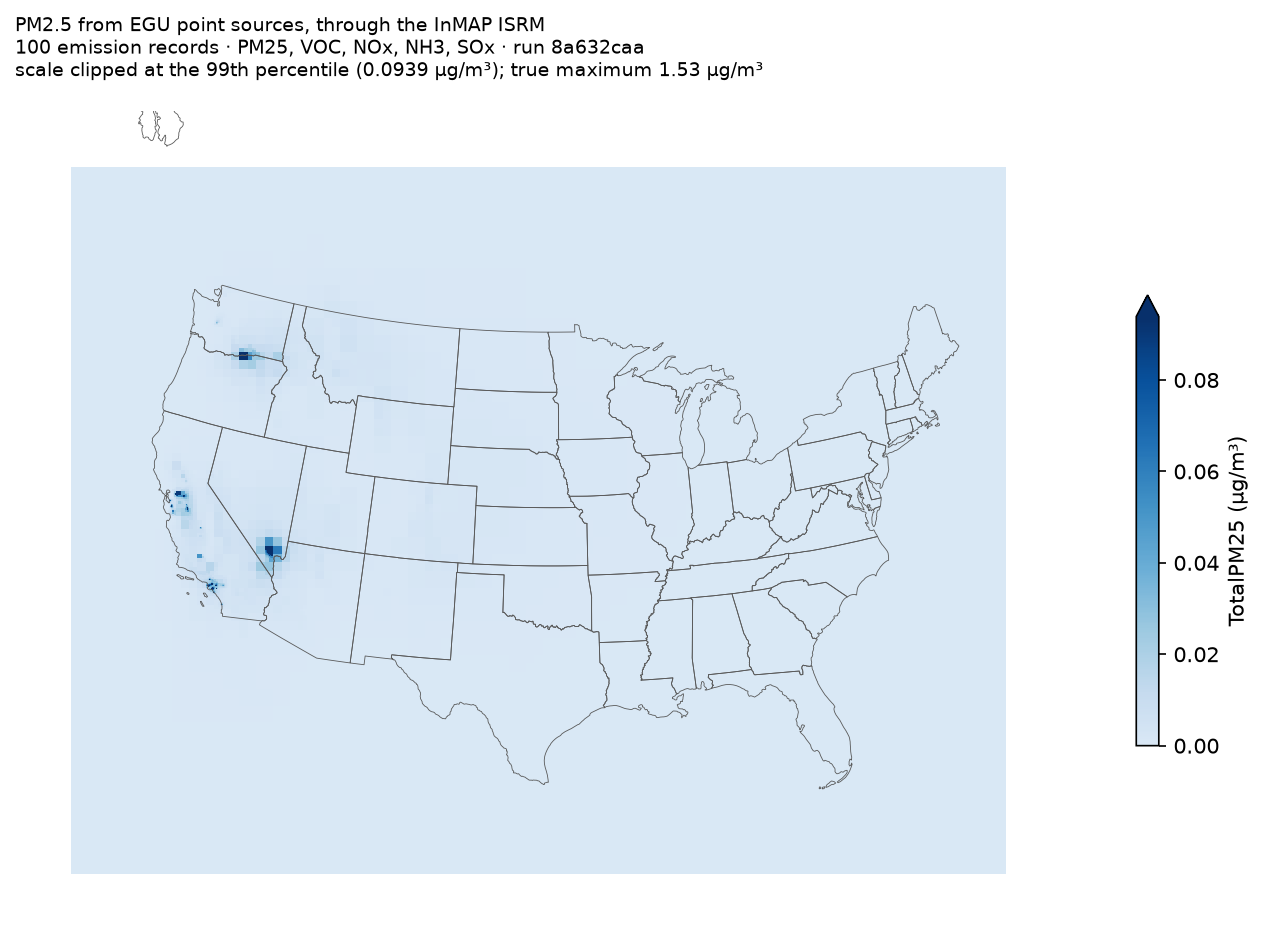

In [25]:
show(point_receptors, "PM2.5 from EGU point sources, through the InMAP ISRM")
plt.show()

---
### Example area source analysis

We can use the same set of functions with a polygon-type geodataframe to simulate impacts of area emission sources. Here, we give all the counties in Illinois a consistent rate of emissions:

In [26]:
COUNTIES_URL = ("https://www2.census.gov/geo/tiger/GENZ2020/shp/"
                "cb_2020_us_county_20m.zip")
STATE = "17"           # Illinois
RATE_PM25 = 1000.0     # kg/yr per km² of land area — an example rate

counties = gpd.read_file(io.BytesIO(download(COUNTIES_URL)))
counties = counties[counties["STATEFP"] == STATE].copy()
counties["PM25"] = RATE_PM25 * counties["ALAND"] / 1e6
polygons = counties[["NAME", "PM25", "geometry"]]
print(f"{len(polygons)} counties · {polygons['PM25'].sum():,.0f} kg/yr of primary PM2.5")
polygons.head(3)

102 counties · 143,778,461 kg/yr of primary PM2.5


,NAME,PM25,geometry
2,Stephenson,1461392.061,"POLYGON ((-89.92647 42.50579, -89.83759 42.504..."
11,Putnam,414649.315,"POLYGON ((-89.46639 41.23387, -89.35673 41.233..."
105,Richland,932484.098,"POLYGON ((-88.25778 38.73114, -88.25858 38.847..."


In [27]:
polygon_receptors = run_isrm(polygons)

layer
  102 records · polygon · nvert_max 56 · PM25
upload
  uploaded emis.zip (32,094 B) as dataset bec630dc-e16d-4d6c-ba6c-bff82fe70e6d
document
  pruned 20 variable(s)/source(s); 1 pathway(s) kept: PrimaryPM25
  isrm_gdf_polygon.esm · poly_vertex width 56 · valid
quote
  cloud_batch · 4.0 vCPU / 16384 MB · 10m00s predicted (cap 1h20m) · $0.04
run
  run 74baed7f-877c-4f68-8319-4df323e75605 — running on cloud_batch, $0.04
  queued
  started
  [####################################### ]  97.6%  elapsed 2m34s
  succeeded in 2m14s of resource time
  sum(TotalPM25)      4219.068006714893
  sum(deathsK)        1406.9517405485624
  sum(deathsL)        3176.194766023125


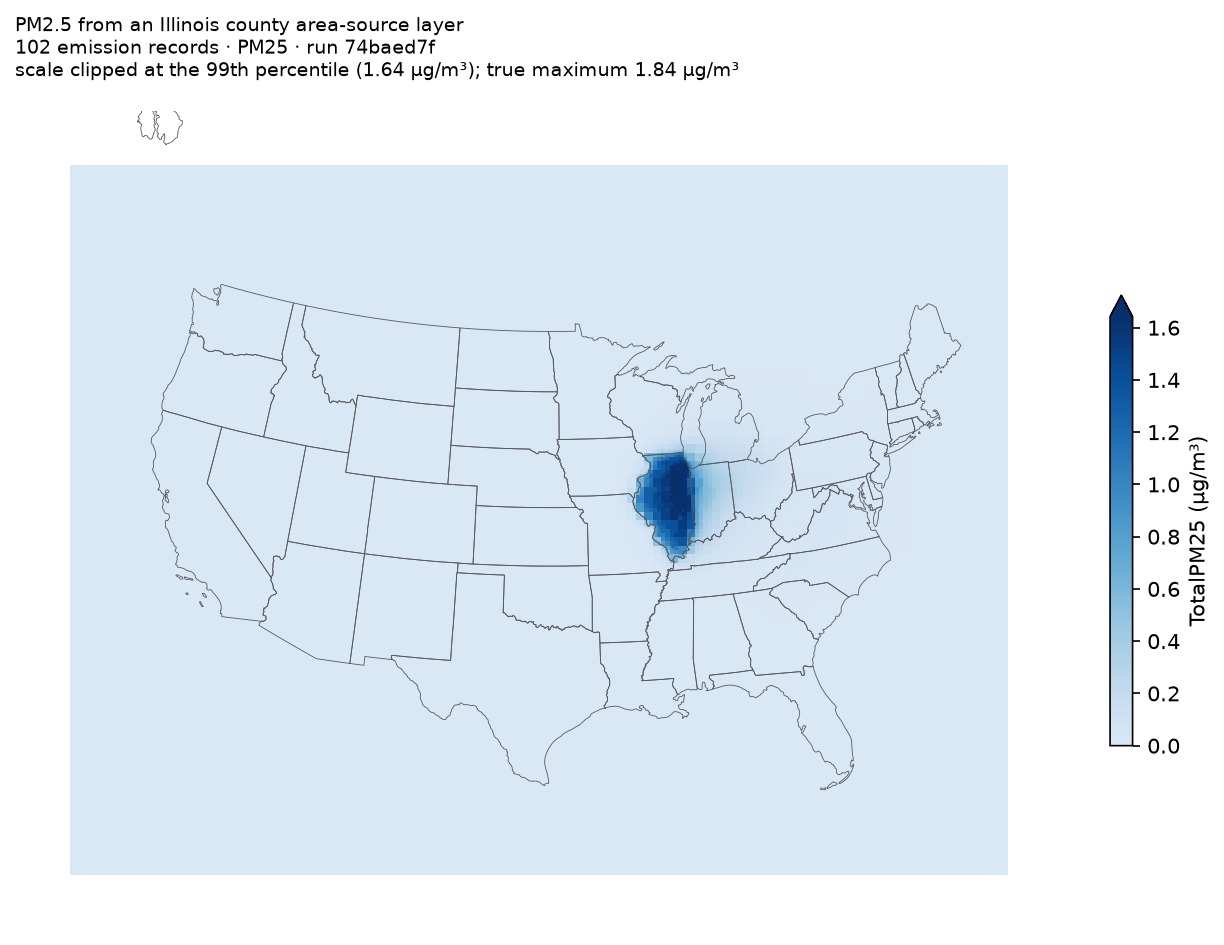

In [28]:
show(polygon_receptors, "PM2.5 from an Illinois county area-source layer")
plt.show()

---
## Example line source analysis

Here, we calculate impacts of emissions on interstates in Illinois, with a constant rate of emission per kilometer of road. Before running the air quality analysis, we simplify the line shapes to reduce computational burden. (We simplify to 200m segments, which is still one fifth of InMAP's smallest grid cells.)

In [29]:
ROADS_URL = (f"https://www2.census.gov/geo/tiger/TIGER2020/PRISECROADS/"
             f"tl_2020_{STATE}_prisecroads.zip")
SIMPLIFY_M = 200.0     # a fifth of the ISRM grid's finest cell
RATE_ROAD_PM25 = 40.0     # kg/yr per km of road — example rates, as above
RATE_ROAD_NOX = 400.0

roads = gpd.read_file(io.BytesIO(download(ROADS_URL)))
interstates = roads[(roads["MTFCC"] == "S1100") & (roads["RTTYP"] == "I")].to_crs(LCC)
interstates["geometry"] = interstates.simplify(SIMPLIFY_M)

km = interstates.length / 1000.0
interstates["PM25"] = RATE_ROAD_PM25 * km
interstates["NOx"] = RATE_ROAD_NOX * km
lines = interstates[["FULLNAME", "PM25", "NOx", "geometry"]]
print(f"{len(lines)} road(s) · {km.sum():,.0f} km · "
      f"{lines['PM25'].sum():,.0f} kg/yr PM2.5, {lines['NOx'].sum():,.0f} kg/yr NOx")
lines.head(3)

292 road(s) · 7,350 km · 294,004 kg/yr PM2.5, 2,940,040 kg/yr NOx


,FULLNAME,PM25,NOx,geometry
4056,I- 57,527.653989,5276.539890,"LINESTRING (729166.377 -47083.84, 729759.571 -..."
4061,I- 355,1153.178387,11531.783871,"LINESTRING (739525.605 227788.524, 739083.546 ..."
4089,I- 294,1434.358024,14343.580243,"LINESTRING (747536.216 242857.167, 747643.526 ..."


In [30]:
line_receptors = run_isrm(lines)

layer
  cut 292 polyline(s) into 1931 two-vertex segment(s)
  1,931 records · line · nvert_max 2 · PM25, NOx
upload
  uploaded emis.zip (280,947 B) as dataset 3295a982-c57f-4c9c-bb72-483cdc82cf28
document
  pruned 15 variable(s)/source(s); 2 pathway(s) kept: PrimaryPM25, pNO3
  isrm_gdf_line.esm · line_vertex width 2 · valid
quote
  cloud_batch · 4.0 vCPU / 16384 MB · 10m00s predicted (cap 1h20m) · $0.04
run
  run 90026046-ca04-4022-b854-3a9313bd29a2 — running on cloud_batch, $0.04
  queued
  started
  [######################################  ]  96.9%  elapsed 2m26s
  succeeded in 2m03s of resource time
  sum(TotalPM25)      42.41880153885225
  sum(deathsK)        13.106555416146492
  sum(deathsL)        29.473888255125694


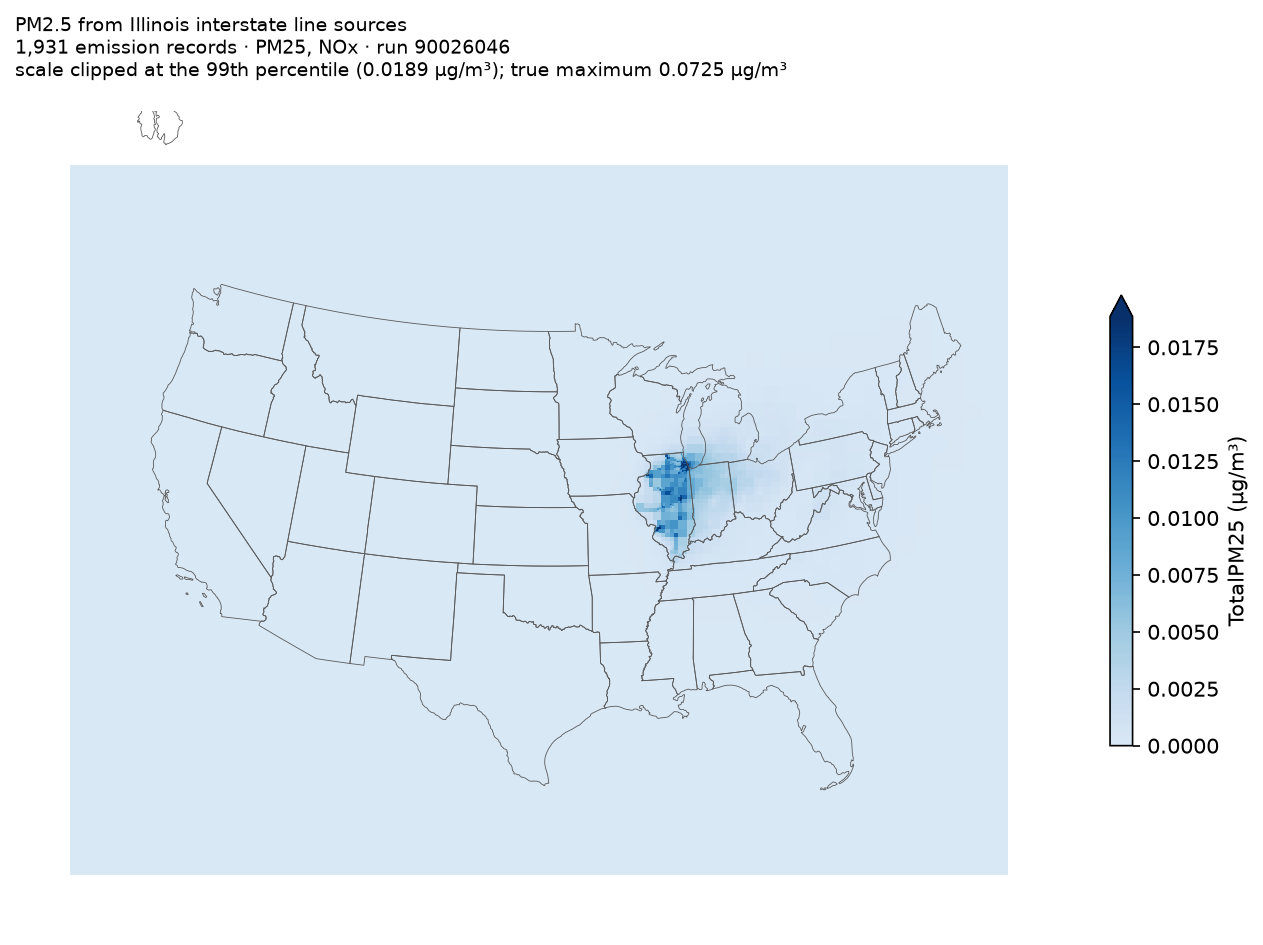

In [31]:
show(line_receptors, "PM2.5 from Illinois interstate line sources")
plt.show()

---
## Cleaning up

Each run uploaded an emissions dataset. You will theoretically be billed for storing these on the server, although the cost for files this size is minimal. The cell below will delete them, you can also do it at https://earthscilab.com.

In [33]:
for receptors in (point_receptors, polygon_receptors, line_receptors):
    dataset_id = receptors.attrs["dataset_id"]
    http_json("DELETE", f"{API}/datasets/{dataset_id}", headers=session.headers())
    print("deleted", dataset_id)

deleted 7e562bc1-6aea-4bdd-aab1-34b0c0b435b0
deleted bec630dc-e16d-4d6c-ba6c-bff82fe70e6d
deleted 3295a982-c57f-4c9c-bb72-483cdc82cf28


## Conclusion

That's all for this tutorial! If you have any questions or run into any issues, feel free to get touch at https://earthsciml.discourse.group/ or https://groups.google.com/g/inmap-users.